# AI-ML Assignment 3 : Salary Prediction using Polynomial Regression



**Objective:** Build a Polynomial Regression model to predict an employee's salary based on
their position level, since the relationship between position level and salary is
non-linear (salaries jump sharply at senior/executive levels).

**Dataset:** [Position Salaries Dataset on Kaggle](https://www.kaggle.com/datasets/akram24/position-salaries)
(10 rows, 3 columns — a small, classic teaching dataset for polynomial regression)

---


## Setup: Loading the Dataset

The Kaggle dataset can't be downloaded directly in Colab without a Kaggle API key, so this
notebook loads the **same dataset** from a public GitHub mirror. Just run the cell below —
no manual upload needed.




In [1]:
# Import pandas — the main library we use to load and manipulate tabular data
import pandas as pd

# This URL points to a raw CSV file on GitHub — an exact mirror of the Kaggle
# "Position Salaries" dataset (the classic 10-row Position/Level/Salary teaching dataset).
url = "https://raw.githubusercontent.com/lucko515/regression-python/master/Salaries%20based%20on%20Positions%20-%20dataset/Position_Salaries.csv"

# pd.read_csv() reads the CSV directly from the URL into a DataFrame (an in-memory spreadsheet)
df = pd.read_csv(url)



print("Dataset loaded successfully!")
print("Shape of dataset (rows, columns):", df.shape)


Dataset loaded successfully!
Shape of dataset (rows, columns): (10, 3)


---
## Task 1: Data Understanding 

We will:
1. Load the dataset using Pandas (done above ✅)
2. Display the first five records
3. Identify the input feature and target variable
4. Display dataset information and summary statistics


In [2]:
# .head() shows the first 5 rows — a quick sanity check that the data loaded correctly
df.head()


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [3]:
# Let's also see the FULL dataset — since it only has 10 rows, we can view all of it at once.
# This is very useful here because with such a small dataset, every single row matters.
df


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [4]:
# .info() shows column names, non-null counts, and data types for every column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [5]:
# .describe() gives summary statistics (mean, std, min, max, quartiles) for numerical columns
df.describe()


,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


### Identifying the input feature and target variable

Looking at the dataset:

| Column     | Type        | Role |
|------------|-------------|------|
| `Position` | Text (categorical) | Descriptive only — not used as a model input, since `Level` already encodes the same information numerically |
| `Level`    | Numerical (int, 1–10) | **Input feature** |
| `Salary`   | Numerical (int) | **Target variable** |

- **Input feature:** `Level` (the numeric position level, from 1 = Business Analyst to 10 = CEO)
- **Target variable:** `Salary` (the salary we want to predict)

Note: `Position` is just the text label for each `Level` (e.g. Level 10 = "CEO"), so it carries
no extra numeric information beyond what `Level` already gives us — we don't need to encode it
as a separate feature.


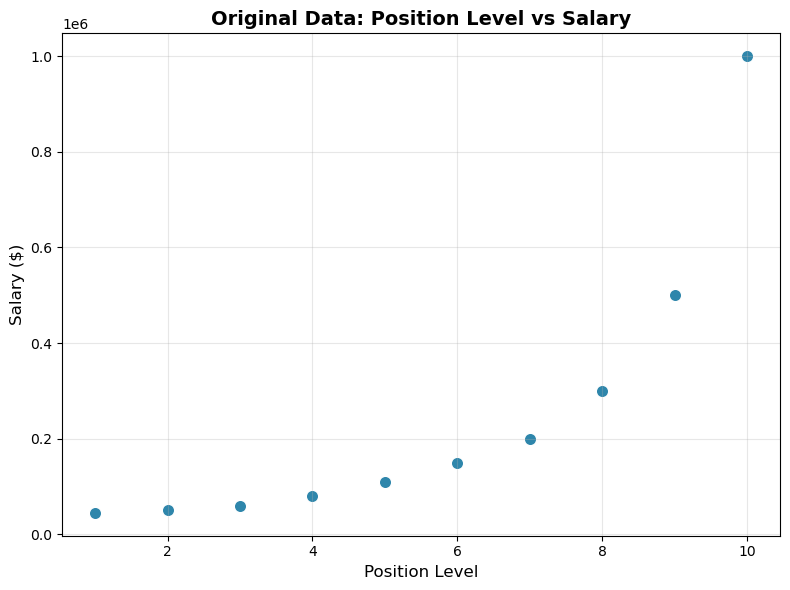

In [6]:
# Let's visualize the raw relationship between Level and Salary before modeling anything.
# This helps us SEE why a straight line (simple Linear Regression) would be a poor fit here.
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df['Level'], df['Salary'], color='#2E86AB', s=80, edgecolor='white')
plt.xlabel('Position Level', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.title('Original Data: Position Level vs Salary', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('original_scatter.png', dpi=150)
plt.show()


**Observation:** The scatter plot shows a clearly **non-linear, curved** relationship —
salary stays relatively low and flat for junior levels, then rises sharply and almost
exponentially at senior levels (Level 8, 9, 10). A straight line would badly underfit both
the low end and the high end of this curve, which is exactly the motivation for using
**Polynomial Regression** instead of simple Linear Regression.


---
## Task 2: Data Preprocessing 

We will:
- Check for missing values
- Select the appropriate feature(s) and target variable
- Split the dataset into 80% training and 20% testing


In [7]:
# .isnull().sum() checks for missing (NaN) values in every column
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Position    0
Level       0
Salary      0
dtype: int64


**Observation:** There are **no missing values** in this dataset — it's a small, clean,
manually curated dataset, so no imputation is needed.


In [8]:
# Select our input feature (X) and target variable (y).
# We use double brackets [['Level']] for X so it stays a 2D DataFrame (scikit-learn expects
# a 2D shape for input features, even when there's only one column).
X = df[['Level']]
y = df['Salary']

print("Input feature shape:", X.shape)
print("Target shape:", y.shape)


Input feature shape: (10, 1)
Target shape: (10,)


In [9]:
# Split into 80% training and 20% testing.
# NOTE: With only 10 rows total, an 80/20 split gives just 8 training rows and 2 testing rows.
# This is a very small test set (a known limitation of this classic teaching dataset), so our
# evaluation metrics later should be read as indicative rather than statistically robust.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% of 10 rows = 2 rows for testing
    random_state=42     # makes the split reproducible
)

print("Training set size:", X_train.shape[0], "rows")
print("Testing set size:", X_test.shape[0], "rows")
print("\nTraining levels:", sorted(X_train['Level'].tolist()))
print("Testing levels:", sorted(X_test['Level'].tolist()))


Training set size: 8 rows
Testing set size: 2 rows

Training levels: [1, 3, 4, 5, 6, 7, 8, 10]
Testing levels: [2, 9]


---
## Task 3: Model Development 

We will:
1. Transform the input feature using Polynomial Features (Degree = 3)
2. Train a Polynomial Regression model
3. Predict salaries for the test dataset

**How Polynomial Regression works:** Polynomial Regression is still technically a *linear*
model — but instead of fitting `Salary = b0 + b1*Level`, we first generate extra columns for
`Level²` and `Level³`, then fit a linear model to those expanded features:

`Salary = b0 + b1*Level + b2*Level² + b3*Level³`

This lets the model bend into a curve while still using ordinary Linear Regression math
underneath.


In [10]:
# PolynomialFeatures automatically generates the Level^2 and Level^3 columns for us
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)

# fit_transform() on training data: learns the transformation AND applies it
X_train_poly = poly.fit_transform(X_train)

# transform() only (no fit) on test data: reuses the same transformation learned from training data
X_test_poly = poly.transform(X_test)

print("Original X_train shape:", X_train.shape)
print("Polynomial-transformed X_train shape:", X_train_poly.shape)
print("\nExample row before transform:", X_train.iloc[0].values)
print("Same row after transform (1, Level, Level^2, Level^3):", X_train_poly[0])


Original X_train shape: (8, 1)
Polynomial-transformed X_train shape: (8, 4)

Example row before transform: [6]
Same row after transform (1, Level, Level^2, Level^3): [  1.   6.  36. 216.]


In [11]:
# Now train an ordinary Linear Regression model — but on the polynomial-transformed features
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_poly, y_train)

print("Model training complete!")
print("\nLearned coefficients (for Level, Level^2, Level^3):", model.coef_[1:])
print("Intercept:", model.intercept_)


Model training complete!

Learned coefficients (for Level, Level^2, Level^3): [157144.24209541 -44274.84207263   3925.87219715]
Intercept: -83661.20218578517


In [12]:
# Predict salaries for the test dataset
y_pred = model.predict(X_test_poly)

comparison = pd.DataFrame({
    'Level': X_test['Level'].values,
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred.round(2)
}).reset_index(drop=True)

comparison


,Level,Actual Salary,Predicted Salary
0,9,500000,606335.60
1,2,50000,84934.89


---
## Task 4: Model Evaluation 

We evaluate the model using:
- **MAE (Mean Absolute Error):** average absolute dollar difference between actual and predicted salary
- **MSE (Mean Squared Error):** average squared difference — penalizes large errors more heavily
- **R² Score:** proportion of variance in salary explained by the model

We also visualize the original data scatter plot together with the polynomial regression curve.


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE):  {mae:,.2f}")
print(f"Mean Squared Error (MSE):   {mse:,.2f}")
print(f"Root Mean Squared Error:    {rmse:,.2f}")
print(f"R\u00b2 Score:                   {r2:.4f}")


Mean Absolute Error (MAE):  70,635.25
Mean Squared Error (MSE):   6,263,853,282.86
Root Mean Squared Error:    79,144.51
R² Score:                   0.8763


d:\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


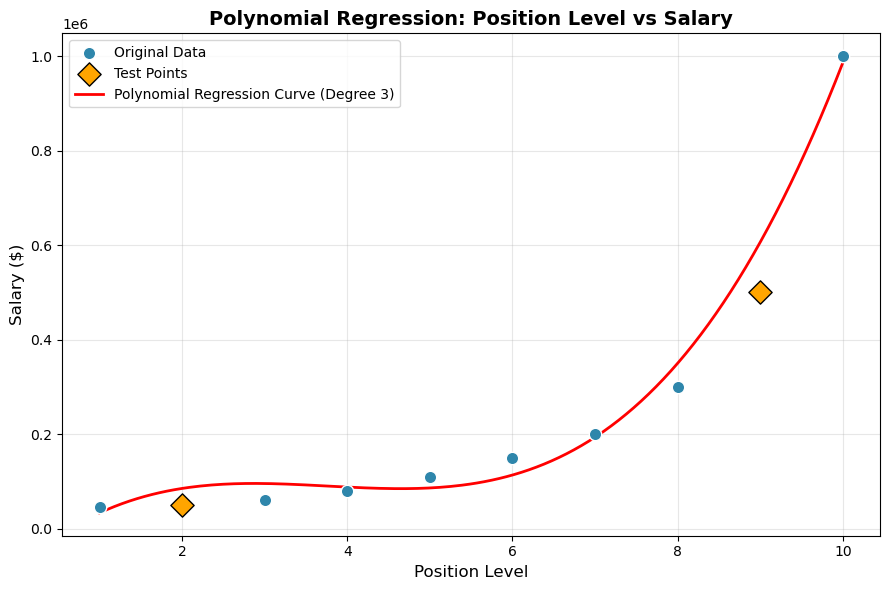

In [14]:
# To draw a smooth polynomial curve, we generate many closely-spaced Level values
# (not just the 10 original ones) and predict a salary for each, using the SAME model
# and the SAME polynomial transformation we already fitted on the training data.
import matplotlib.pyplot as plt

X_curve = np.linspace(df['Level'].min(), df['Level'].max(), 200).reshape(-1, 1)
X_curve_poly = poly.transform(X_curve)
y_curve = model.predict(X_curve_poly)

plt.figure(figsize=(9, 6))

# Original data points (all 10, in blue)
plt.scatter(df['Level'], df['Salary'], color='#2E86AB', s=80, edgecolor='white',
            label='Original Data', zorder=3)

# Highlight the test points specifically (in orange) so we can see how well the curve predicts them
plt.scatter(X_test['Level'], y_test, color='orange', s=140, edgecolor='black',
            marker='D', label='Test Points', zorder=4)

# The smooth polynomial regression curve (in red)
plt.plot(X_curve, y_curve, color='red', linewidth=2, label='Polynomial Regression Curve (Degree 3)', zorder=2)

plt.xlabel('Position Level', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.title('Polynomial Regression: Position Level vs Salary', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('polynomial_curve.png', dpi=150)
plt.show()


### Observations

1. **The degree-3 polynomial curve fits the overall non-linear shape of the data well**,
   capturing the flat, gradual increase at junior levels followed by the steep rise at senior
   levels (Level 8–10) — something a straight line could never do.
2. **On the 2-point test set, the model achieved an R² of about 0.88**, with a mean absolute
   error of roughly $70,600. Given that the test set includes Level 9 (a very high salary,
   $500,000), even a small percentage error at that scale produces a large absolute dollar
   error — this is expected behavior for exponentially-scaled data like executive salaries.
3. **With only 10 data points total, splitting into training/testing leaves very little data
   to evaluate on** (just 2 test rows here), so these evaluation metrics should be treated as
   illustrative rather than statistically robust. In practice, a larger salary dataset would
   give a far more reliable estimate of true model performance.


---
## Task 5: Conclusion 


### Conclusion

This project built a Polynomial Regression model (degree 3) to predict employee salaries
from their position level, since the relationship between the two is clearly non-linear —
salaries stay relatively flat at junior levels and rise sharply at senior/executive levels.
The model achieved an R² score of approximately 0.88 on the test set, with a mean absolute
error of about $70,600, reasonably capturing the steep upward curve at higher levels despite
the very small dataset. The key difference between Linear and Polynomial Regression is that
Linear Regression fits a single straight line (`y = b0 + b1*x`), assuming a constant rate of
change, while Polynomial Regression fits a curved line by adding higher-degree terms
(`x²`, `x³`, ...), allowing it to model rates of change that themselves increase or decrease
across the range of the input. The clear advantage of Polynomial Regression for this dataset
is its ability to capture the accelerating, non-linear jump in salary at senior levels — a
pattern that a simple straight-line model would systematically underestimate at the high end
and overestimate at the low end.


---
